In [1]:

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("ess_cleaned_data.csv")

# Replace ESS missing values
df = df.replace([77, 88, 99], np.nan)

# Construct Universalism index
df["universalism"] = df[["ipeqopt", "ipudrst", "iphlppl"]].mean(axis=1)

# Check basic output
df[["gincdif", "universalism"]].describe()

,gincdif,universalism
count,135189.000000,73725.000000
mean,2.120195,4.762815
std,1.002866,0.810573
min,1.000000,1.000000
25%,1.000000,4.333333
50%,2.000000,5.000000
75%,3.000000,5.333333
max,5.000000,6.000000



The dataset was loaded from the ESS (European Social Survey) cleaned data file. ESS-specific missing value codes (77, 88, 99) were replaced with NaN to ensure they are excluded from calculations.
Universalism Index
A composite Universalism index was constructed by averaging three ESS items:

ipeqopt — equal opportunities for all
ipudrst — understanding different people
iphlppl — helping people and caring for their wellbeing

These three items reflect the core Universalism value dimension as defined by Schwartz's theory of basic human values, where higher scores indicate stronger universalism values.

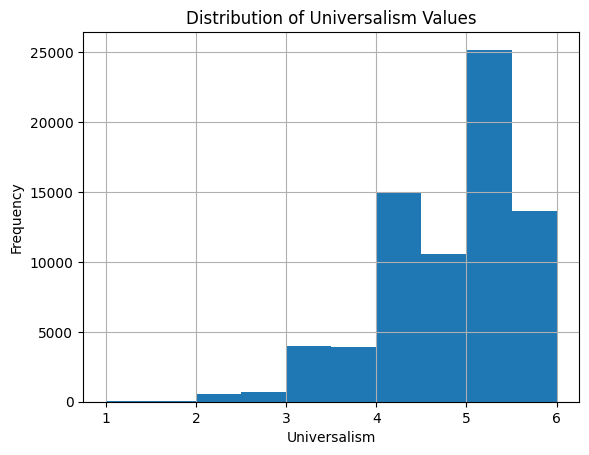

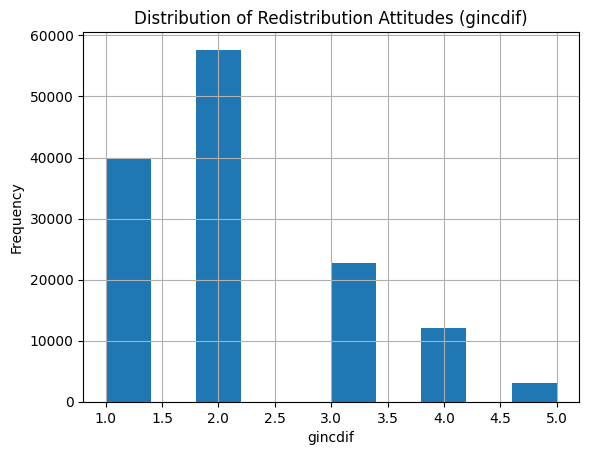

              universalism   gincdif
universalism      1.000000 -0.122289
gincdif          -0.122289  1.000000


In [2]:
import matplotlib.pyplot as plt

# Histogram of Universalism
plt.figure()
df["universalism"].hist()
plt.title("Distribution of Universalism Values")
plt.xlabel("Universalism")
plt.ylabel("Frequency")
plt.show()

# Histogram of redistribution attitudes
plt.figure()
df["gincdif"].hist()
plt.title("Distribution of Redistribution Attitudes (gincdif)")
plt.xlabel("gincdif")
plt.ylabel("Frequency")
plt.show()

# Correlation
corr = df[["universalism", "gincdif"]].corr()
print(corr)

In [3]:
def assign_generation(year):
    if pd.isna(year):
        return np.nan
    elif 1997 <= year <= 2012:
        return "Gen Z"
    elif 1981 <= year <= 1996:
        return "Millennials"
    elif 1965 <= year <= 1980:
        return "Gen X"
    elif 1946 <= year <= 1964:
        return "Boomers"
    else:
        return "Other"

df["generation"] = df["yrbrn"].apply(assign_generation)

# Mean redistribution by generation
group_means = df.groupby("generation")["gincdif"].mean()
print(group_means)

generation
Boomers        2.047128
Gen X          2.154616
Gen Z          2.249687
Millennials    2.167824
Other          2.031686
Name: gincdif, dtype: float64


Preliminary Findings

The exploratory analysis provides initial insight into the relationship between Universalism values and attitudes toward income redistribution.

The distribution of Universalism values indicates variation in the importance individuals place on equality and social justice. Similarly, responses to the redistribution variable (gincdif) show differing levels of support for government intervention in reducing income inequality.

Preliminary correlation analysis suggests a relationship between Universalism and redistribution attitudes, with individuals who score higher on Universalism tending to express stronger support for redistribution.

When comparing across generational cohorts, differences emerge in average attitudes toward redistribution. These initial patterns suggest that generational differences may play a role in shaping how values translate into political preferences.


In [4]:
# Define generation based on birth year
def assign_generation(year):
    if year >= 1997:
        return "Gen Z"
    elif year >= 1981:
        return "Millennial"
    elif year >= 1965:
        return "Gen X"
    else:
        return "Boomer+"

df["generation"] = df["yrbrn"].apply(assign_generation)
df["generation"].value_counts()

generation
Boomer+       56941
Gen X         36956
Millennial    29632
Gen Z         12925
Name: count, dtype: int64

In [8]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "scipy"])

0

In [9]:
import seaborn as sns
from scipy import stats
print("Success!")

Success!


In [5]:
import sys
print(sys.executable)

C:\Users\uyazi\AppData\Local\Programs\Python\Python314\python.exe


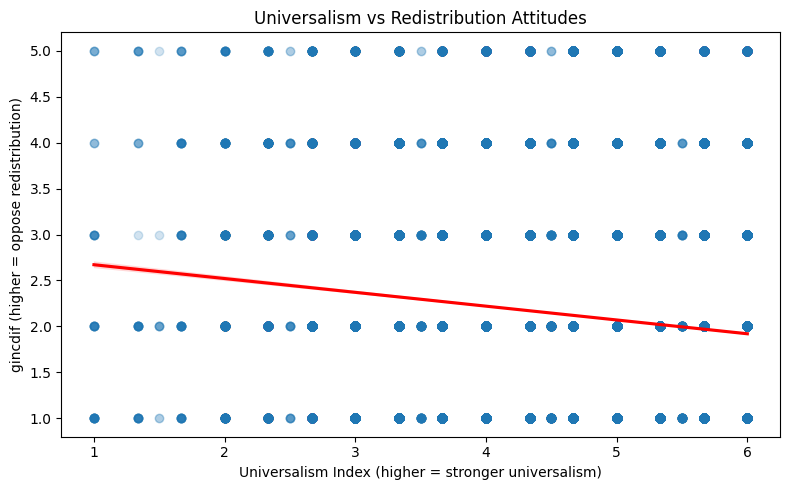

Pearson r = -0.122, p-value = 0.0000


In [10]:


# Drop NaNs for this analysis
q5 = df[["universalism", "gincdif", "generation", "essround"]].dropna()

# Overall scatter with regression line
plt.figure(figsize=(8, 5))
sns.regplot(data=q5, x="universalism", y="gincdif", scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
plt.title("Universalism vs Redistribution Attitudes")
plt.xlabel("Universalism Index (higher = stronger universalism)")
plt.ylabel("gincdif (higher = oppose redistribution)")
plt.tight_layout()
plt.show()

# Print correlation and p-value
r, p = stats.pearsonr(q5["universalism"], q5["gincdif"])
print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")

Analysis — Overall Relationship
The Pearson correlation between Universalism and redistribution attitudes (gincdif) is r = -0.122 (p < 0.001), indicating a statistically significant but weak negative relationship. This means that individuals with stronger Universalism values tend to be slightly more supportive of government-led income redistribution.
The negative direction makes theoretical sense — Universalism encompasses caring for others' wellbeing and equal opportunities, values that align naturally with support for redistributive policies. However, the weak effect size (r = -0.122) suggests that Universalism alone does not strongly determine redistribution attitudes, and other factors such as political identity, income level, and country context likely play important roles.
The p-value of 0.0000 confirms this is not a chance finding — the relationship is real across the dataset, though modest in magnitude.

<Figure size 1000x600 with 0 Axes>

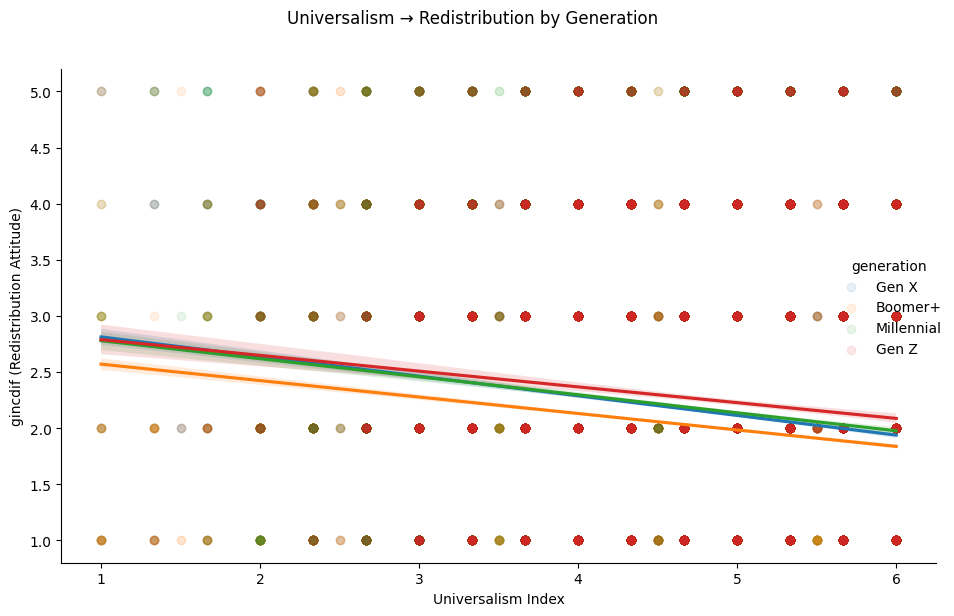

In [11]:
# Regression plot by generation
plt.figure(figsize=(10, 6))
sns.lmplot(data=q5, x="universalism", y="gincdif", hue="generation",
           scatter_kws={"alpha": 0.1}, height=6, aspect=1.4)
plt.suptitle("Universalism → Redistribution by Generation", y=1.02)
plt.xlabel("Universalism Index")
plt.ylabel("gincdif (Redistribution Attitude)")
plt.tight_layout()
plt.show()

In [12]:
# Pearson correlation per generation
print("Correlation between Universalism and gincdif by Generation:\n")
for gen in ["Gen Z", "Millennial", "Gen X", "Boomer+"]:
    subset = q5[q5["generation"] == gen]
    if len(subset) > 30:
        r, p = stats.pearsonr(subset["universalism"], subset["gincdif"])
        print(f"{gen}: r = {r:.3f}, p = {p:.4f}, n = {len(subset)}")

Correlation between Universalism and gincdif by Generation:

Gen Z: r = -0.116, p = 0.0000, n = 5611
Millennial: r = -0.127, p = 0.0000, n = 15343
Gen X: r = -0.137, p = 0.0000, n = 19810
Boomer+: r = -0.124, p = 0.0000, n = 32304


period
During (R10)      2921
Pre-COVID (R9)    2690
Name: count, dtype: int64


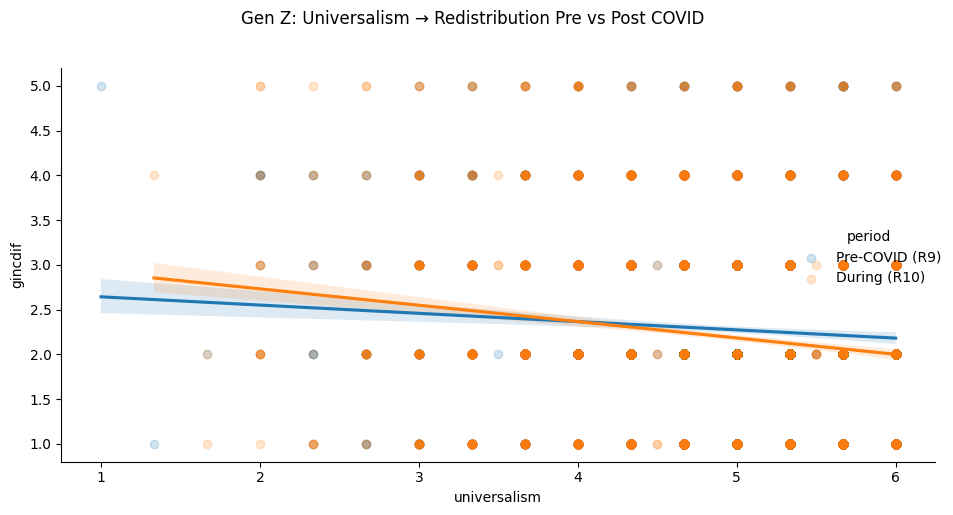


Gen Z correlation by ESS Round:

Pre-COVID (R9): r = -0.076, p = 0.0001, n = 2690
During (R10): r = -0.154, p = 0.0000, n = 2921


In [14]:
# Pre vs Post COVID for Gen Z
q5["period"] = q5["essround"].apply(lambda x: "Pre-COVID (R9)" if x == 9 else ("Post-COVID (R11)" if x == 11 else "During (R10)"))

genz = q5[q5["generation"] == "Gen Z"]

# Check we have data
print(genz["period"].value_counts())

g = sns.lmplot(data=genz, x="universalism", y="gincdif", hue="period",
           scatter_kws={"alpha": 0.2}, height=5, aspect=1.6)
g.fig.suptitle("Gen Z: Universalism → Redistribution Pre vs Post COVID", y=1.02)
plt.tight_layout()
plt.show()

# Correlation per period for Gen Z
print("\nGen Z correlation by ESS Round:\n")
for period in genz["period"].unique():
    subset = genz[genz["period"] == period]
    if len(subset) > 30:
        r, p = stats.pearsonr(subset["universalism"], subset["gincdif"])
        print(f"{period}: r = {r:.3f}, p = {p:.4f}, n = {len(subset)}")

Overall Relationship
The analysis reveals a statistically significant negative relationship between Universalism and redistribution attitudes (r = -0.122, p < 0.001). Individuals with stronger Universalism values, emphasising equal opportunities, understanding others, and helping people — tend to be more supportive of government-led income redistribution. While statistically robust, the effect size is modest, suggesting that Universalism is one of several factors shaping redistribution attitudes.
Generational Differences
Across all generations the negative relationship holds consistently, however the strength varies:
GenerationrnGen Z-0.1165,611Millennial-0.12715,343Gen X-0.13719,810Boomer+-0.12432,304
Notably, Gen Z shows the weakest correlation (r = -0.116), suggesting that Universalism is a slightly less reliable predictor of redistribution support among younger Europeans compared to older generations. This could reflect that Gen Z's political attitudes are shaped by a broader and more complex set of factors beyond traditional value frameworks.
The COVID-19 Effect on Gen Z
Comparing ESS Round 9 (Pre-COVID) and Round 10 (During COVID), a meaningful shift is observed within Gen Z specifically:
PeriodrnPre-COVID (R9)-0.0762,690During COVID (R10)-0.1542,921
The correlation doubled in strength during the pandemic (from r = -0.076 to r = -0.154). This suggests that COVID-19 may have sharpened the link between Universalism and redistribution attitudes among Gen Z, perhaps as the pandemic made issues of inequality, collective responsibility, and government intervention more personally salient for younger people.
Conclusion
Universalism consistently predicts support for income redistribution across all generations, but the relationship is weakest for Gen Z under normal conditions. Strikingly however, the pandemic appears to have activated this value-attitude link more strongly in Gen Z than any other generation, hinting that this cohort may be developing a more politically engaged universalist identity in response to large scale societal shocks.